In [1]:
import os
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BUSIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # The three classes in the dataset
        self.classes = ['normal', 'benign', 'malignant']
        
        for label, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            
            if not os.path.exists(class_dir):
                print(f"Warning: Could not find folder {class_dir}")
                continue
                
            for file_name in os.listdir(class_dir):
                # Only load the actual images, skip the segmentation masks
                if 'mask' not in file_name:
                    full_path = os.path.join(class_dir, file_name)
                    self.image_paths.append(full_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Convert to RGB because VGG16 expects 3 channels for vgg16
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("Custom Dataset class defined successfully.")

Custom Dataset class defined successfully.


In [2]:
# Data Loading and Dataloaders

import torchvision.transforms as transforms

DATASET_PATH = '/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'

transform = transforms.Compose([
    transforms.Resize((224, 224)),       # VGG16 requires 224x224 input
    transforms.ToTensor(),               # Convert to PyTorch Tensor [0, 1]
    transforms.Normalize(                # ImageNet normalization standards
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# Load and Split Dataset
full_dataset = BUSIDataset(root_dir=DATASET_PATH, transform=transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total images loaded: {len(full_dataset)}")
print(f"Training on {len(train_dataset)} images, Testing on {len(test_dataset)} images.")

Total images loaded: 780
Training on 624 images, Testing on 156 images.


In [3]:
# Cell 4: The Ultimate VGG16 Configuration

import torchvision.models as models
import torch.nn as nn  # for loss function
import torch.optim as optim
import numpy as np


# 1. Load VGG16 with Standard ImageNet Weights
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# 2. Advanced Fine-Tuning: 
# Freeze the early layers (keep the basic edge detection)
for param in vgg16.features.parameters():
    param.requires_grad = False

# UNFREEZE the last few layers (Block 5) so it learns medical textures
for param in vgg16.features[24:].parameters():
    param.requires_grad = True

# 3. The "Diet" Classifier to fight memorization
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 256),      
    nn.ReLU(),                  
    nn.Dropout(p=0.5),          # 50% Dropout
    nn.Linear(256, 3)           # 3 Classes
)

vgg16 = vgg16.to(device)

# 4. The Imbalance Fix: Class Weights
train_labels = [train_dataset.dataset.labels[i] for i in train_dataset.indices]
class_counts = np.bincount(train_labels)
class_weights = len(train_labels) / class_counts
weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# 5. Optimizer with a very slow learning rate 
# (Because we unfroze convolutional layers, we must train them gently)
optimizer = optim.Adam(vgg16.parameters(), lr=0.00001, weight_decay=1e-3)

print("VGG16 armed with Class Weights, Dropout, and Fine-Tuning!")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 203MB/s]


VGG16 armed with Class Weights, Dropout, and Fine-Tuning!


In [4]:
# Train and Track Metrics
EPOCHS = 10

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training and tracking...\n")

for epoch in range(EPOCHS):
    vgg16.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    #  TESTING/VALIDATION PHASE
    vgg16.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    test_loss = val_loss / len(test_loader)
    test_acc = 100 * val_correct / val_total
    
    # Save the metrics for graphing
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting training and tracking...

Epoch [1/10] | Train Acc: 50.00% | Test Acc: 67.95%
Epoch [2/10] | Train Acc: 76.12% | Test Acc: 78.85%
Epoch [3/10] | Train Acc: 79.33% | Test Acc: 75.00%
Epoch [4/10] | Train Acc: 83.17% | Test Acc: 76.92%
Epoch [5/10] | Train Acc: 88.46% | Test Acc: 80.77%
Epoch [6/10] | Train Acc: 90.38% | Test Acc: 81.41%
Epoch [7/10] | Train Acc: 93.59% | Test Acc: 82.05%
Epoch [8/10] | Train Acc: 95.03% | Test Acc: 83.97%
Epoch [9/10] | Train Acc: 95.83% | Test Acc: 82.05%
Epoch [10/10] | Train Acc: 97.60% | Test Acc: 84.62%


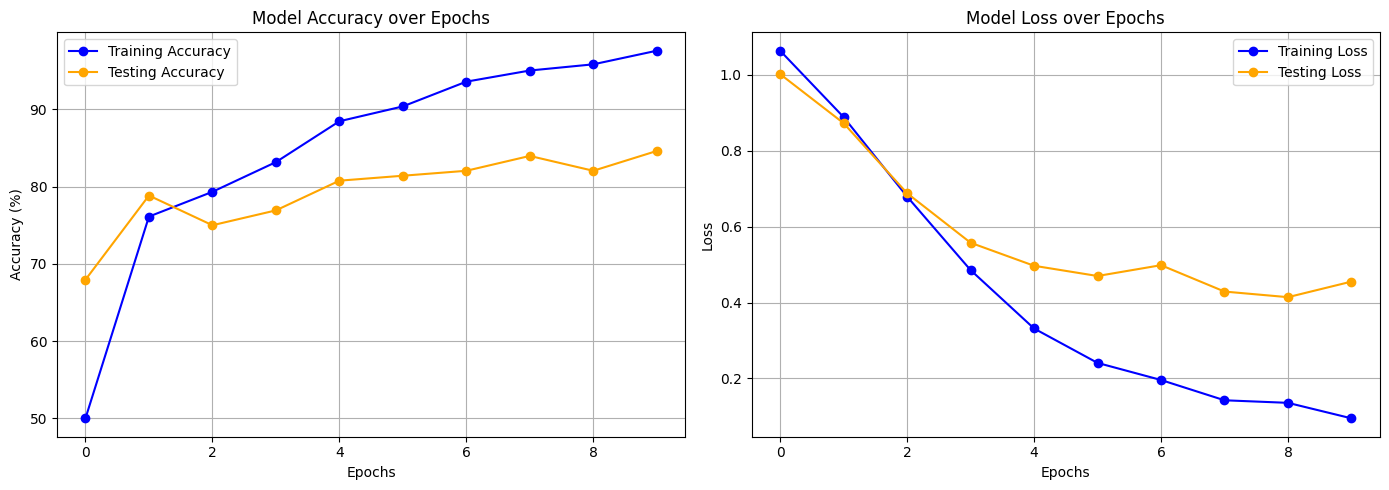

In [5]:
#  Visualize Training Progress
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

#  Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.plot(test_accuracies, label='Testing Accuracy', color='orange', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(test_losses, label='Testing Loss', color='orange', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

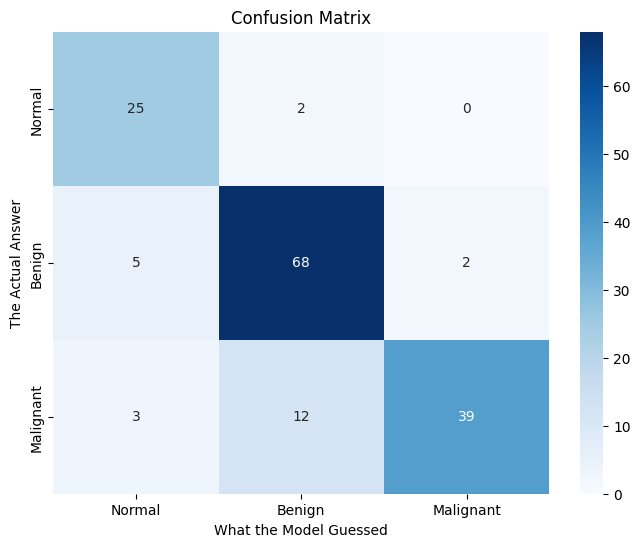


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.93      0.83        27
      Benign       0.83      0.91      0.87        75
   Malignant       0.95      0.72      0.82        54

    accuracy                           0.85       156
   macro avg       0.85      0.85      0.84       156
weighted avg       0.86      0.85      0.84       156



In [6]:
#  Confusion Matrix and Classification Report
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

#  Gather all predictions and true labels
all_preds = []
all_labels = []

vgg16.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vgg16(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Draw the Confusion Matrix
class_names = ['Normal', 'Benign', 'Malignant']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Answer')
plt.show()

# Print the detailed mathematical report
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))